# MTReLD 结果对比（author vs my）

本 notebook 会解析并对比两份日志：

- `author.txt`：作者原始实现（`final/reld-nco/Multi-Task/test.py`）的推理输出，包含 **ReLD-MTL** 与 **ReLD-MoE-light** 两个版本。
- `my.txt`：平台移植实现（`final/eval.py`）的推理输出，包含 **mtreld_mtl** 与 **mtreld** 两个版本。

提取并对齐每个问题的：
- `no_aug_score`：不使用 8-fold augmentation，仅在 POMO 里取最优（作者称 NO-AUG SCORE）。
- `aug_score`：在 8-fold augmentation + POMO 中取最优（作者称 AUGMENTATION SCORE）。

最后输出：每个问题的数值对比、差值（my - author）、以及简单统计/可视化。


In [30]:
from __future__ import annotations

import re
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

plt.rcParams['figure.dpi'] = 120


In [31]:
# --- Path helpers ---

def resolve_log(name: str) -> Path:
    # 1) if notebook is run inside the log folder
    candidates = [
        Path.cwd() / name,
        # 2) if notebook is run from repo root
        Path.cwd() / 'final/logs/tsplib_70/lehd' / name,
    ]
    for p in candidates:
        if p.exists():
            return p

    # 3) last resort: search (may be slow on huge repos, but OK here)
    hits = list(Path.cwd().rglob(name))
    if hits:
        return hits[0]

    raise FileNotFoundError(f"Cannot find {name!r}. Tried: {candidates[:2]}")


author_path = resolve_log('author.txt')
my_path = resolve_log('my.txt')

print('author_path =', author_path)
print('my_path     =', my_path)


author_path = /mnt/d/Study/3/neural-solver-selection/final/logs/tsplib_70/lehd/author.txt
my_path     = /mnt/d/Study/3/neural-solver-selection/final/logs/tsplib_70/lehd/my.txt


In [32]:
# --- Parsers ---

AUTHOR_CMD_RE = re.compile(r"python test\.py.*?--model_type=(MTL|MOE_LIGHT)")
AUTHOR_BLOCK_RE = re.compile(
    r"\*\*\* Test Done on (?P<problem>\w+) \*\*\*"  # header
    r".*?NO-AUG SCORE: (?P<no_aug>[0-9.]+), Gap: (?P<no_aug_gap>[-+]?[0-9.]+)"  # no-aug
    r".*?AUGMENTATION SCORE: (?P<aug>[0-9.]+), Gap: (?P<aug_gap>[-+]?[0-9.]+)",  # aug
    re.S,
)


def parse_author(path: Path) -> pd.DataFrame:
    text = path.read_text(errors='ignore')
    cmd_matches = list(AUTHOR_CMD_RE.finditer(text))
    if not cmd_matches:
        raise ValueError('No author command markers found (python test.py --model_type=...).')

    rows = []
    for i, m in enumerate(cmd_matches):
        variant = m.group(1)
        start = m.end()
        end = cmd_matches[i + 1].start() if i + 1 < len(cmd_matches) else len(text)
        section = text[start:end]

        for b in AUTHOR_BLOCK_RE.finditer(section):
            rows.append(
                {
                    'source': 'author',
                    'variant': variant,
                    'problem': b.group('problem').upper(),
                    'no_aug_score': float(b.group('no_aug')),
                    'aug_score': float(b.group('aug')),
                    'no_aug_gap': float(b.group('no_aug_gap')),
                    'aug_gap': float(b.group('aug_gap')),
                }
            )

    df = pd.DataFrame(rows)
    if df.empty:
        raise ValueError('Parsed author df is empty. Regex may not match the log format.')
    return df.sort_values(['variant', 'problem']).reset_index(drop=True)


PL_PROB_RE = re.compile(r"^=====\s*测试\s+([A-Za-z0-9_]+)\s+\(")
PL_MODEL_RE = re.compile(r"\[INFO\]\s+-\s+model:\s+(\w+)")
PL_AUG_RE = re.compile(r"^\s*aug_score\s+([0-9.]+)\s*$")
PL_NOAUG_RE = re.compile(r"^\s*no_aug_score\s+([0-9.]+)\s*$")


def parse_platform(path: Path) -> pd.DataFrame:
    text = path.read_text(errors='ignore')
    current_problem = None
    current_model = None
    run_aug = None
    run_no_aug = None
    rows = []

    def flush_if_ready():
        nonlocal run_aug, run_no_aug
        if current_problem and current_model and run_aug is not None and run_no_aug is not None:
            rows.append(
                {
                    'source': 'my',
                    'variant': current_model,
                    'problem': current_problem.upper(),
                    'no_aug_score': float(run_no_aug),
                    'aug_score': float(run_aug),
                }
            )
            run_aug = None
            run_no_aug = None

    for line in text.splitlines():
        m = PL_PROB_RE.match(line)
        if m:
            # new problem section
            flush_if_ready()
            current_problem = m.group(1)
            continue

        m = PL_MODEL_RE.search(line)
        if m:
            # new model run (within the same problem)
            flush_if_ready()
            current_model = m.group(1)
            continue

        m = PL_AUG_RE.match(line)
        if m:
            run_aug = float(m.group(1))
            flush_if_ready()
            continue

        m = PL_NOAUG_RE.match(line)
        if m:
            run_no_aug = float(m.group(1))
            flush_if_ready()
            continue

    flush_if_ready()

    df = pd.DataFrame(rows)
    if df.empty:
        raise ValueError('Parsed platform df is empty. Regex may not match the log format.')
    # keep last occurrence if duplicated
    df = df.sort_values(['variant', 'problem']).drop_duplicates(['variant', 'problem'], keep='last')
    return df.reset_index(drop=True)


In [33]:
author_df = parse_author(author_path)
my_df = parse_platform(my_path)

print('author_df:', author_df.shape)
display(author_df.head())
print('my_df:', my_df.shape)
display(my_df.head())


author_df: (32, 7)


,source,variant,problem,no_aug_score,aug_score,no_aug_gap,aug_gap
0,author,MOE_LIGHT,CVRP,15.8353,15.7134,2.1500,1.3541
1,author,MOE_LIGHT,OVRP,10.1861,10.0504,3.6469,2.2595
2,author,MOE_LIGHT,OVRPB,8.9715,8.8041,7.2394,5.2390
3,author,MOE_LIGHT,OVRPBL,8.9491,8.7861,7.1968,5.2465
4,author,MOE_LIGHT,OVRPBLTW,15.8459,15.5500,11.2374,9.1713


my_df: (32, 5)


,source,variant,problem,no_aug_score,aug_score
0,my,mtreld,CVRP,15.835250,15.713436
1,my,mtreld,OVRP,10.186061,10.050372
2,my,mtreld,OVRPB,8.971494,8.804092
3,my,mtreld,OVRPBL,8.949051,8.786096
4,my,mtreld,OVRPBLTW,15.845943,15.549978


## 对齐关系

作者与平台的命名对应：

- 作者 `MTL`  ⇔ 平台 `mtreld_mtl`
- 作者 `MOE_LIGHT` ⇔ 平台 `mtreld`


In [34]:
pairs = [
    ('MTL', 'mtreld_mtl'),
    ('MOE_LIGHT', 'mtreld'),
]

# sanity check: what variants exist
print('author variants:', sorted(author_df['variant'].unique().tolist()))
print('my variants    :', sorted(my_df['variant'].unique().tolist()))


author variants: ['MOE_LIGHT', 'MTL']
my variants    : ['mtreld', 'mtreld_mtl']


In [35]:
def build_comparison(author_variant: str, my_variant: str) -> pd.DataFrame:
    a = author_df[author_df['variant'] == author_variant].set_index('problem')
    b = my_df[my_df['variant'] == my_variant].set_index('problem')

    out = a[['no_aug_score', 'aug_score', 'no_aug_gap', 'aug_gap']].rename(
        columns={
            'no_aug_score': 'author_no_aug',
            'aug_score': 'author_aug',
            'no_aug_gap': 'author_no_aug_gap',
            'aug_gap': 'author_aug_gap',
        }
    ).join(
        b[['no_aug_score', 'aug_score']].rename(
            columns={'no_aug_score': 'my_no_aug', 'aug_score': 'my_aug'}
        ),
        how='outer',
    )

    out['diff_no_aug'] = out['my_no_aug'] - out['author_no_aug']
    out['diff_aug'] = out['my_aug'] - out['author_aug']
    out['diff_no_aug_pct'] = out['diff_no_aug'] / out['author_no_aug'] * 100
    out['diff_aug_pct'] = out['diff_aug'] / out['author_aug'] * 100

    out = out.reset_index().rename(columns={'problem': 'problem'})
    return out.sort_values('problem')


cmp = {f'{a} vs {b}': build_comparison(a, b) for a, b in pairs}
for k, df in cmp.items():
    print('===', k, '===')
    display(df)


=== MTL vs mtreld_mtl ===


,problem,author_no_aug,author_aug,author_no_aug_gap,author_aug_gap,my_no_aug,my_aug,diff_no_aug,diff_aug,diff_no_aug_pct,diff_aug_pct
0,CVRP,15.8365,15.7228,2.1542,1.4163,15.836527,15.722804,0.000027,0.000004,0.000170,0.000026
1,OVRP,10.1916,10.0565,3.6968,2.3213,10.191556,10.056503,-0.000044,0.000003,-0.000432,0.000033
2,OVRPB,8.9712,8.8141,7.2325,5.3607,8.971177,8.814149,-0.000023,0.000049,-0.000255,0.000555
3,OVRPBL,8.9569,8.7999,7.2961,5.4105,8.956874,8.799862,-0.000026,-0.000038,-0.000291,-0.000433
4,OVRPBLTW,15.8493,15.5552,11.2748,9.2148,15.849317,15.555179,0.000017,-0.000021,0.000105,-0.000137
5,OVRPBTW,16.0094,15.7112,11.3592,9.2879,16.009445,15.711170,0.000045,-0.000030,0.000282,-0.000190
6,OVRPL,10.1499,10.0144,3.6982,2.3100,10.149908,10.014375,0.000008,-0.000025,0.000079,-0.000252
7,OVRPLTW,14.9190,14.7212,4.5388,3.1593,14.919019,14.721206,0.000019,0.000006,0.000126,0.000039
8,OVRPTW,15.0091,14.8177,4.4254,3.1030,15.009109,14.817746,0.000009,0.000046,0.000063,0.000312
9,VRPB,12.1096,11.9805,1.9953,0.9010,12.109627,11.980508,0.000027,0.000008,0.000221,0.000066


=== MOE_LIGHT vs mtreld ===


,problem,author_no_aug,author_aug,author_no_aug_gap,author_aug_gap,my_no_aug,my_aug,diff_no_aug,diff_aug,diff_no_aug_pct,diff_aug_pct
0,CVRP,15.8353,15.7134,2.1500,1.3541,15.835250,15.713436,-0.000050,0.000036,-0.000316,0.000230
1,OVRP,10.1861,10.0504,3.6469,2.2595,10.186061,10.050372,-0.000039,-0.000028,-0.000384,-0.000277
2,OVRPB,8.9715,8.8041,7.2394,5.2390,8.971494,8.804092,-0.000006,-0.000008,-0.000070,-0.000086
3,OVRPBL,8.9491,8.7861,7.1968,5.2465,8.949051,8.786096,-0.000049,-0.000004,-0.000549,-0.000050
4,OVRPBLTW,15.8459,15.5500,11.2374,9.1713,15.845943,15.549978,0.000043,-0.000022,0.000274,-0.000140
5,OVRPBTW,15.9916,15.6966,11.2364,9.1836,15.991627,15.696645,0.000027,0.000045,0.000167,0.000285
6,OVRPL,10.1424,10.0068,3.6188,2.2331,10.142352,10.006809,-0.000048,0.000009,-0.000472,0.000092
7,OVRPLTW,14.9120,14.7070,4.4954,3.0540,14.911969,14.707045,-0.000031,0.000045,-0.000207,0.000303
8,OVRPTW,15.0105,14.8035,4.4392,3.0000,15.010536,14.803545,0.000036,0.000045,0.000241,0.000304
9,VRPB,12.1035,11.9691,1.9392,0.8012,12.103498,11.969131,-0.000002,0.000031,-0.000013,0.000255


In [36]:
# --- Summary stats ---

def summarize(df: pd.DataFrame) -> pd.DataFrame:
    tmp = df.copy()
    # drop missing comparisons
    tmp = tmp.dropna(subset=['author_no_aug', 'my_no_aug', 'author_aug', 'my_aug'])
    return pd.DataFrame(
        {
            'mean_abs_diff_no_aug': [tmp['diff_no_aug'].abs().mean()],
            'max_abs_diff_no_aug': [tmp['diff_no_aug'].abs().max()],
            'mean_abs_diff_aug': [tmp['diff_aug'].abs().mean()],
            'max_abs_diff_aug': [tmp['diff_aug'].abs().max()],
        }
    )

for k, df in cmp.items():
    print('===', k, 'summary ===')
    display(summarize(df))


=== MTL vs mtreld_mtl summary ===


,mean_abs_diff_no_aug,max_abs_diff_no_aug,mean_abs_diff_aug,max_abs_diff_aug
0,0.000027,0.00005,0.000024,0.000049


=== MOE_LIGHT vs mtreld summary ===


,mean_abs_diff_no_aug,max_abs_diff_no_aug,mean_abs_diff_aug,max_abs_diff_aug
0,0.000027,0.00005,0.000029,0.00005


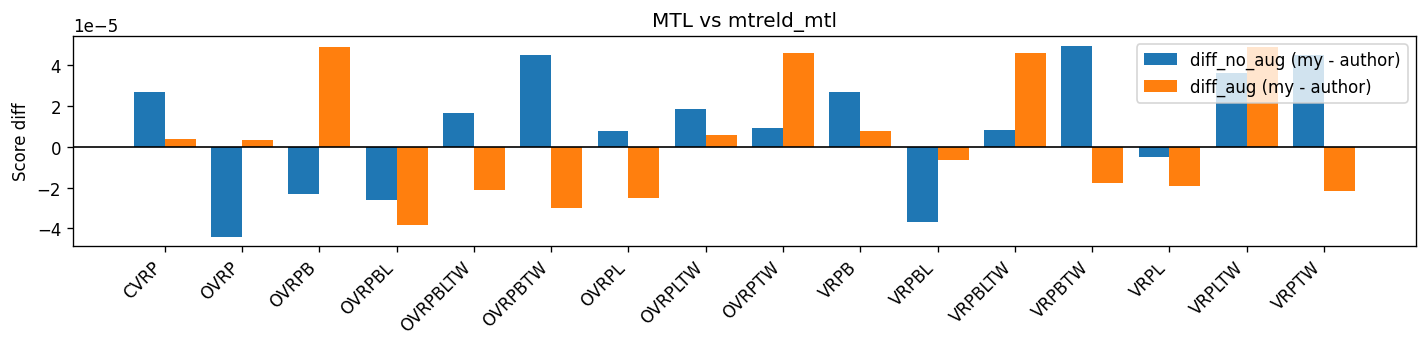

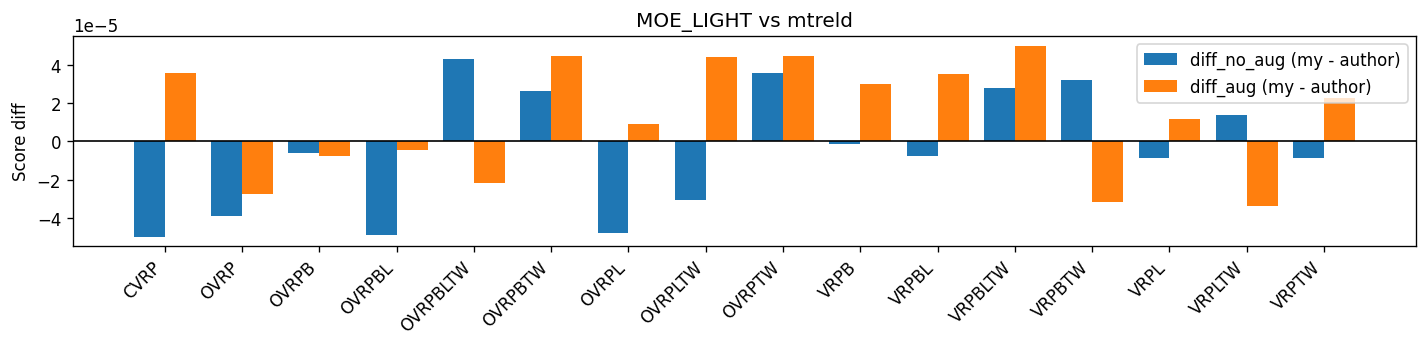

In [37]:
# --- Visualize diffs ---

for k, df in cmp.items():
    plot_df = df.dropna(subset=['diff_no_aug', 'diff_aug']).copy()
    plot_df = plot_df.sort_values('problem')

    fig, ax = plt.subplots(1, 1, figsize=(12, 3))
    x = np.arange(len(plot_df))
    ax.bar(x - 0.2, plot_df['diff_no_aug'], width=0.4, label='diff_no_aug (my - author)')
    ax.bar(x + 0.2, plot_df['diff_aug'], width=0.4, label='diff_aug (my - author)')
    ax.axhline(0, color='black', linewidth=1)
    ax.set_xticks(x)
    ax.set_xticklabels(plot_df['problem'], rotation=45, ha='right')
    ax.set_ylabel('Score diff')
    ax.set_title(k)
    ax.legend(loc='upper right')
    plt.tight_layout()
    plt.show()


## 备注（如何解释“差一点点”）

如果你看到平台与作者数值存在极小差异，最常见来源是：

- **非确定性/数值精度**：TF32、matmul precision、cudnn 是否 deterministic。
- **输入 dtype 的细节**：例如 multi-task env 里的 `open` 在作者 env 是 float(0/1)，如果平台用 bool 可能导致线性层输入差异。
- **augmentation 的实现细节**：8-fold 变换是否包含 depot、是否完全一致的变换顺序。

本仓库中我们已在 `final/eval.py`、`final/neural_solvers/envs/MVRPEnv.py` 等处做了对齐；若仍有差异，可以从“差值最大的 problem”入手进一步定位。
